# Temporal band-pass filtering of a single PIVlab run

Filters the two velocity components at **every grid point along time**, keeping only the content
between two user-defined cut-offs `[F_LOW, F_HIGH]`, and writes the result next to the original:

    <run>/PIVlab_results_uncalibrated.mat
      ->  <run>/PIVlab_results_uncalibrated_bp0.04-0.20Hz.mat

### Units — nothing is calibrated, by design
The source `.mat` is **already uncalibrated**: `u`/`v` are pixel displacements per laser pulse pair
and `x`/`y` are pixels. Filtering is linear, so scaling and filtering commute — there is no need to
convert to m/s and back, and this notebook never does. Everything stays in native PIVlab units, so
the output is a **drop-in replacement** for the input (same variables, shapes and dtypes) and any
downstream tool calibrates it exactly as it calibrates the original.

The only calibrated quantity a temporal filter needs is **time**, read from `acquisition_log.txt`:

    fps = cam_fps / FRAMES_PER_FIELD

because PIVlab pairs images, so one velocity field is produced every 2 camera frames. Cut-offs are
therefore in Hz **of the PIV field rate**, with Nyquist = `fps/2`. This differs between runs — check
what the diagnostics cell reports rather than assuming.

### Filter
Zero-phase Butterworth (`scipy.signal.sosfiltfilt`): no phase shift, so filtered structures stay
where they were in time. The series is passed forwards and backwards, so the effective order is
twice `FILTER_ORDER`.

| condition | result |
|---|---|
| `F_LOW <= 0` | low-pass at `F_HIGH` |
| `F_HIGH >= Nyquist` | high-pass at `F_LOW` |
| otherwise | band-pass `[F_LOW, F_HIGH]` |

NaNs are interpolated along time before filtering (`filtfilt` would otherwise smear a single NaN
across the whole series) and restored afterwards, so the validity pattern of `u`/`v` is preserved
exactly.

### Edge transients — read this before trusting a low `F_LOW`
A Butterworth band-pass settles over roughly **1/`F_LOW` seconds**, and `sosfiltfilt`'s default
padding is only a few dozen samples — orders of magnitude too short for sub-Hz cut-offs. Left
uncorrected it leaks rejected content into the start and end of the record: on a 50 s record with
`F_LOW = 0.04 Hz`, a pure 0.5 Hz tone that the filter rejects by 60 dB came back at 15% of its
amplitude, concentrated in the first 10 s.

The padding is therefore stretched to `PAD_SETTLING_TIMES / F_LOW` (capped at the record length),
which cuts that leakage by ~65×. It **cannot be removed entirely**: if the record is shorter than a
few 1/`F_LOW`, the first and last ~1/`F_LOW` seconds stay unreliable whatever the padding. Cell 3
warns when that applies — the fix is a longer record or a higher `F_LOW`.

In [ ]:
import os

import numpy as np
from scipy import signal
from scipy.io import loadmat, savemat, whosmat

import matplotlib.pyplot as plt

%matplotlib inline

from piv_common import (FRAMES_PER_FIELD, LOG_FILENAME, PIV_FILENAME, PTS_ROI,
                        XSCALE, YSCALE, calibrate, create_mask, region_tag,
                        read_acquisition_params)

plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

## 1. User settings

In [ ]:
# ----------------------------------------------------------------------
# USER SETTINGS -- normally the only cell you need to touch
# ----------------------------------------------------------------------
# PIV_FILENAME, LOG_FILENAME, XSCALE, YSCALE and FRAMES_PER_FIELD come from
# piv_common (imported above); only the run and the filter live here.

RUN_DIR = ('/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/'
           'CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib0.500Hz_dphi2deg_SS1')

# --- Cut-off frequencies [Hz], in the PIV FIELD rate (not the camera rate) ---
F_LOW  = 0.07
F_HIGH = 0.2

FILTER_ORDER = 4            # per direction; sosfiltfilt doubles it (zero-phase)

# Padding used by sosfiltfilt, in filter settling times (~1/F_LOW). The scipy
# default is a few dozen samples -- far too short for sub-Hz cut-offs, which
# leaves large transients at both ends of the record.
PAD_SETTLING_TIMES = 3.0

# Velocity variables to filter. u/v are the pre-validation fields (they carry the
# NaN validity pattern), u_filt/v_filt the validated ones the analyses read.
VEL_VARS = ('u', 'v', 'u_filt', 'v_filt')

# correlation_map describes the raw image correlation, not the filtered velocity,
# so it is meaningless once filtered -- and it is ~108 MB.
KEEP_CORRELATION_MAP = False

QUIVER_SKIP   = 3           # quiver plot (cell 7): draw every n-th vector
# The filtered .mat is ALWAYS the full field. This only sets which region the
# cell-7 quiver PREVIEW shows: 'full' or 'ROI' (zoomed to PTS_ROI).
QUIVER_REGION = 'FULL'

# The output is never silently clobbered; set True to regenerate it.
OVERWRITE = False

## 2. Functions

In [ ]:
def design_filter(fps, f_low, f_high, order=FILTER_ORDER):
    """Butterworth SOS for the requested band. Returns (sos, kind, lo, hi)."""
    nyq = fps / 2.0
    lo = None if (f_low is None or f_low <= 0) else float(f_low)
    hi = None if (f_high is None or f_high >= nyq) else float(f_high)

    if lo is not None and lo >= nyq:
        raise ValueError('f_low (%g Hz) is at or above Nyquist (%g Hz): '
                         'nothing would survive' % (lo, nyq))
    if lo is None and hi is None:
        raise ValueError('band [%s, %s] Hz spans the whole spectrum at fps=%g Hz: '
                         'nothing to filter' % (f_low, f_high, fps))
    if lo is not None and hi is not None:
        if lo >= hi:
            raise ValueError('f_low (%g) must be below f_high (%g)' % (lo, hi))
        return signal.butter(order, [lo, hi], btype='bandpass', fs=fps,
                             output='sos'), 'bandpass', lo, hi
    if hi is not None:
        return signal.butter(order, hi, btype='lowpass', fs=fps,
                             output='sos'), 'lowpass', None, hi
    return signal.butter(order, lo, btype='highpass', fs=fps,
                         output='sos'), 'highpass', lo, None


def _fill_nans_time(A):
    """Interpolate NaNs along the last (time) axis. Returns (filled, nan_mask).

    filtfilt propagates a single NaN over the entire series, so gaps are bridged
    first and masked back out afterwards. Points that are NaN for all time are
    zero-filled and fully re-masked.
    """
    nan_mask = np.isnan(A)
    if not nan_mask.any():
        return A, nan_mask

    filled = A.copy()
    nt = A.shape[-1]
    idx = np.arange(nt)
    all_nan = nan_mask.all(axis=-1)

    for i, j in np.argwhere(nan_mask.any(axis=-1)):
        if all_nan[i, j]:
            filled[i, j, :] = 0.0
            continue
        s = filled[i, j, :]
        m = nan_mask[i, j, :]
        s[m] = np.interp(idx[m], idx[~m], s[~m])
    return filled, nan_mask


def settling_padlen(sos, nt, fps, lo, hi, n_settle=PAD_SETTLING_TIMES):
    """Padding matched to the filter's settling time, in samples.

    A Butterworth filter settles over ~1/f_ref seconds, f_ref being its lowest
    cut-off. scipy's default padding is 3*(2*n_sections+1) samples, which for a
    sub-Hz cut-off is orders of magnitude too short and leaves the first and last
    seconds of the output full of transient. Capped at nt-1, the most sosfiltfilt
    accepts.
    """
    minimum = 3 * (2 * len(sos) + 1)
    f_ref = lo if lo is not None else hi
    want = minimum if not f_ref else int(np.ceil(n_settle * fps / f_ref))
    return int(min(max(want, minimum), nt - 1))


def filter_field(A, sos, padlen=None):
    """Zero-phase filter a (ny, nx, nt) field along time, preserving NaNs."""
    A = np.asarray(A, dtype=float)
    filled, nan_mask = _fill_nans_time(A)
    kw = {} if padlen is None else {'padlen': padlen}
    try:
        out = signal.sosfiltfilt(sos, filled, axis=-1, **kw)
    except ValueError as exc:
        raise ValueError('filtering failed (%s). The record is probably too short '
                         'for this filter order -- lower FILTER_ORDER.' % exc)
    out[nan_mask] = np.nan
    return out


def output_filename(orig_name, kind, lo, hi):
    """Original name + a tag describing the band, e.g. ..._bp0.04-0.20Hz.mat."""
    stem, ext = os.path.splitext(orig_name)
    if kind == 'bandpass':
        tag = 'bp%.2f-%.2fHz' % (lo, hi)
    elif kind == 'lowpass':
        tag = 'lp%.2fHz' % hi
    else:
        tag = 'hp%.2fHz' % lo
    return '%s_%s%s' % (stem, tag, ext)

## 3. Inspect the run and the requested band

Nothing is read into memory here beyond the variable list, so this is cheap to re-run while you
settle on the cut-offs.

In [ ]:
piv_path = os.path.join(RUN_DIR, PIV_FILENAME)
log_path = os.path.join(RUN_DIR, LOG_FILENAME)
if not os.path.isfile(piv_path):
    raise FileNotFoundError(piv_path)

_, fps, ok = read_acquisition_params(log_path)
if not ok:
    raise RuntimeError('could not read cam_fps from %s -- the cut-offs cannot be '
                       'interpreted without the sampling rate' % log_path)

shapes = dict((n, s) for n, s, _ in whosmat(piv_path))
ny, nx, nt = shapes['u_filt']
T = nt / fps

sos, kind, lo, hi = design_filter(fps, F_LOW, F_HIGH, FILTER_ORDER)
out_path = os.path.join(RUN_DIR, output_filename(PIV_FILENAME, kind, lo, hi))

print('run        :', os.path.basename(os.path.normpath(RUN_DIR)))
print('grid       : %d x %d vectors, %d frames' % (ny, nx, nt))
print('fps        : %g Hz  (PIV field rate = cam_fps/%d)   Nyquist %g Hz'
      % (fps, FRAMES_PER_FIELD, fps / 2))
print('record     : %.2f s   -> lowest resolvable frequency 1/T = %.4f Hz' % (T, 1 / T))
print('filter     : %s, Butterworth order %d, zero-phase (effective %d)'
      % (kind, FILTER_ORDER, 2 * FILTER_ORDER))
if lo is not None:
    print('   f_low   : %.4f Hz  -> %5.1f cycles in the record' % (lo, lo * T))
if hi is not None:
    print('   f_high  : %.4f Hz  -> %5.1f cycles in the record' % (hi, hi * T))
padlen = settling_padlen(sos, nt, fps, lo, hi)
f_ref = lo if lo is not None else hi
print('padding    : %d samples (%.1f s) -- the filter settles over ~1/f_ref = %.1f s'
      % (padlen, padlen / fps, 1.0 / f_ref))
print('output     :', os.path.basename(out_path))
if os.path.isfile(out_path):
    print('             exists already (%.0f MB) -- set OVERWRITE = True to regenerate'
          % (os.path.getsize(out_path) / 1e6))

# The record must span several settling times, or the ends are transient.
if T < PAD_SETTLING_TIMES / f_ref:
    print()
    print('WARNING: f_ref = %.4f Hz needs ~%.0f s to settle, but the record is only'
          % (f_ref, PAD_SETTLING_TIMES / f_ref))
    print('         %.1f s (%.1f cycles at f_ref, 1/T = %.4f Hz). The padding below'
          % (T, f_ref * T, 1 / T))
    print('         suppresses most of the leakage, but the first and last ~%.0f s of'
          % (1.0 / f_ref,))
    print('         the filtered record still carry edge transients -- do not trust')
    print('         them. Raise F_LOW, or use a longer record.')

## 4. Filter response

The applied response is the **square** of the single-pass Butterworth response, because
`sosfiltfilt` runs the filter forwards and then backwards. That is what makes it zero-phase, and it
also makes the roll-off twice as steep as the nominal order suggests.

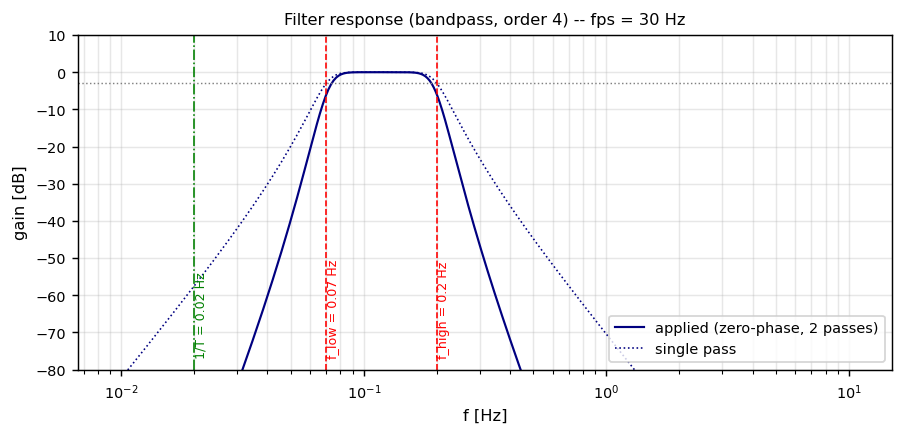

In [36]:
w, h = signal.sosfreqz(sos, worN=8192, fs=fps)
mag = 20 * np.log10(np.maximum(np.abs(h), 1e-12))

fig, ax = plt.subplots(figsize=(7, 3.4), dpi=130)
ax.semilogx(w[1:], 2 * mag[1:], color='navy', lw=1.2, label='applied (zero-phase, 2 passes)')
ax.semilogx(w[1:], mag[1:], color='navy', ls=':', lw=0.9, label='single pass')
for f, lab in ((lo, 'f_low'), (hi, 'f_high')):
    if f is not None:
        ax.axvline(f, color='red', ls='--', lw=0.9)
        ax.text(f, -78, ' %s = %.3g Hz' % (lab, f), color='red', fontsize=7,
                rotation=90, va='bottom')
ax.axvline(1 / T, color='green', ls='-.', lw=0.9)
ax.text(1 / T, -78, ' 1/T = %.3g Hz' % (1 / T), color='green', fontsize=7,
        rotation=90, va='bottom')
ax.axhline(-3, color='grey', ls=':', lw=0.8)
ax.set_xlim(min(1 / T / 3, (lo or fps / 2) / 3), fps / 2)
ax.set_ylim(-80, 10)
ax.set_xlabel('f [Hz]')
ax.set_ylabel('gain [dB]')
ax.set_title('Filter response (%s, order %d) -- fps = %g Hz' % (kind, FILTER_ORDER, fps))
ax.grid(alpha=0.3, which='both')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

## 5. Filter and save

Every original variable is carried across (so the PIV settings survive) with the four velocity
fields replaced by their filtered versions, plus `filter_*` provenance fields so a filtered file can
never be mistaken for a raw one.

In [37]:
if os.path.isfile(out_path) and not OVERWRITE:
    print('output already exists, nothing written:')
    print('   ', out_path)
    print('set OVERWRITE = True in the settings cell to regenerate it')
else:
    names = [n for n, _, _ in whosmat(piv_path)]
    skip = set() if KEEP_CORRELATION_MAP else {'correlation_map'}
    wanted = [n for n in names if n not in skip]

    mat = loadmat(piv_path, variable_names=wanted)
    mat = {k: v for k, v in mat.items() if not k.startswith('__')}

    for var in VEL_VARS:
        if var not in mat:
            print('  ! %s absent, skipped' % var)
            continue
        before = mat[var]
        after = filter_field(before, sos, padlen=padlen)
        rms_in = float(np.sqrt(np.nanmean(before ** 2)))
        rms_out = float(np.sqrt(np.nanmean(after ** 2)))
        print('  %-7s rms %.4f -> %.4f px/pulse   (%.1f%% of the variance kept)'
              % (var, rms_in, rms_out, 100 * (rms_out / rms_in) ** 2 if rms_in else np.nan))
        mat[var] = after

    mat.update({
        'filter_type': kind,
        'filter_f_low_Hz': np.nan if lo is None else lo,
        'filter_f_high_Hz': np.nan if hi is None else hi,
        'filter_order': FILTER_ORDER,
        'filter_zero_phase': 1,
        'filter_padlen': padlen,
        'filter_fps_Hz': fps,
        'filter_source_file': PIV_FILENAME,
        'filter_units': 'unchanged from source: px displacement per pulse pair',
    })
    if not KEEP_CORRELATION_MAP and 'correlation_map' in names:
        mat['filter_dropped'] = 'correlation_map'

    savemat(out_path, mat, do_compression=True)
    print()
    print('wrote %s  (%.1f MB)' % (os.path.basename(out_path),
                                   os.path.getsize(out_path) / 1e6))
    del mat

  u       rms 0.5835 -> 0.1281 px/pulse   (4.8% of the variance kept)
  v       rms 0.5444 -> 0.1218 px/pulse   (5.0% of the variance kept)
  u_filt  rms 0.4978 -> 0.1155 px/pulse   (5.4% of the variance kept)
  v_filt  rms 0.4780 -> 0.1100 px/pulse   (5.3% of the variance kept)

wrote PIVlab_results_uncalibrated_bp0.07-0.20Hz.mat  (413.8 MB)


## 6. Check the result

Re-reads `u_filt` from the original **and from the file just written**, so this checks what actually
landed on disk rather than what was in memory. The spectrum of the filtered series should collapse
outside the shaded pass band, and the time series should keep its features in place (zero phase),
just without the fast wiggles or the slow drift.

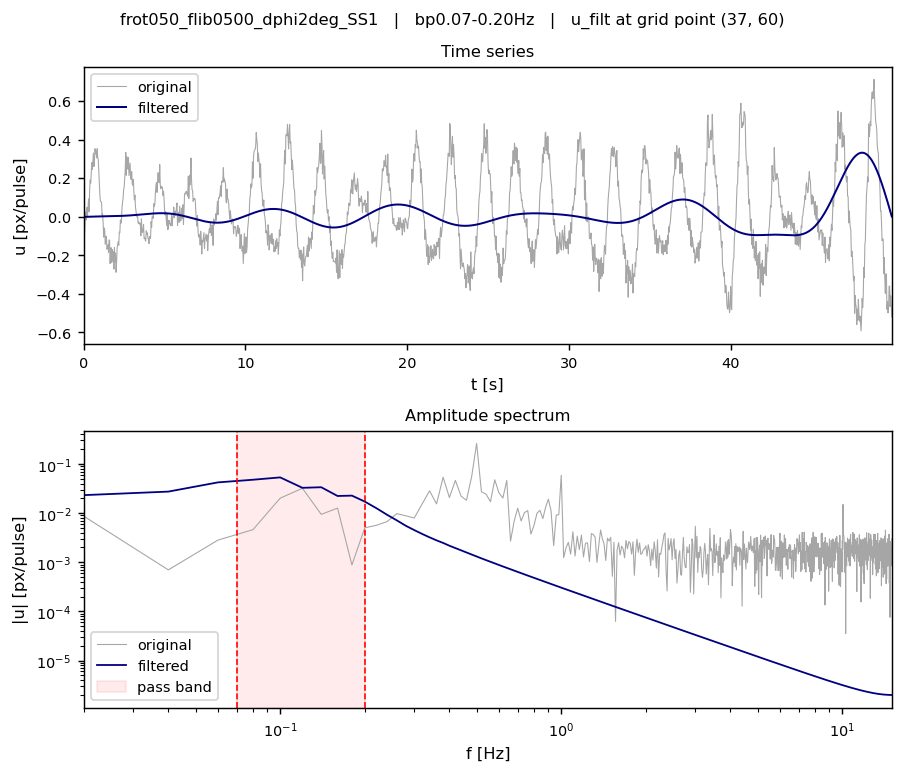

variance kept at this point : 12.5 %
rms  0.2198 -> 0.0777 px/pulse


In [38]:
i, j = ny // 2, nx // 2

a = loadmat(piv_path, variable_names=['u_filt'])['u_filt'][i, j, :]
b = loadmat(out_path, variable_names=['u_filt'])['u_filt'][i, j, :]


def amp_spec(s, fps):
    """Single-sided amplitude spectrum of a 1-D series, mean removed."""
    s = s - np.nanmean(s)
    n = s.size
    return np.fft.rfftfreq(n, 1.0 / fps), np.abs(np.fft.rfft(s)) * 2.0 / n


fa, Aa = amp_spec(a, fps)
fb, Ab = amp_spec(b, fps)
t = np.arange(a.size) / fps

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), dpi=130)
fig.suptitle('%s   |   %s   |   u_filt at grid point (%d, %d)'
             % (os.path.basename(os.path.normpath(RUN_DIR)),
                output_filename(PIV_FILENAME, kind, lo, hi).split('_')[-1].replace('.mat', ''),
                i, j), fontsize=9)

ax1.plot(t, a, color='0.65', lw=0.6, label='original')
ax1.plot(t, b, color='navy', lw=1.1, label='filtered')
ax1.set_xlim(t[0], t[-1])
ax1.set_xlabel('t [s]')
ax1.set_ylabel('u [px/pulse]')
ax1.set_title('Time series')
ax1.legend()

ax2.loglog(fa[1:], Aa[1:], color='0.65', lw=0.6, label='original')
ax2.loglog(fb[1:], Ab[1:], color='navy', lw=1.0, label='filtered')
ax2.axvspan(lo if lo is not None else fa[1], hi if hi is not None else fps / 2,
            color='red', alpha=0.08, label='pass band')
for f in (lo, hi):
    if f is not None:
        ax2.axvline(f, color='red', ls='--', lw=0.9)
ax2.set_xlim(fa[1], fps / 2)
ax2.set_xlabel('f [Hz]')
ax2.set_ylabel('|u| [px/pulse]')
ax2.set_title('Amplitude spectrum')
ax2.legend()

fig.tight_layout()
plt.show()

kept = np.nansum(Ab[1:] ** 2) / np.nansum(Aa[1:] ** 2)
print('variance kept at this point : %.1f %%' % (100 * kept))
print('rms  %.4f -> %.4f px/pulse' % (np.sqrt(np.nanmean((a - np.nanmean(a)) ** 2)),
                                      np.sqrt(np.nanmean((b - np.nanmean(b)) ** 2))))

## 7. Calibrated velocity field — quiver over speed

One PIV field taken from the **middle of the record**, calibrated to metres and m/s for display.

The mid-point is deliberate rather than arbitrary: a zero-phase filter leaves its edge transients at
the two ends of the record, so the middle frame is the furthest from both and the safest single
field to look at.

This is the **only** cell that applies the calibration (`XSCALE`, and `pulse_sep` from the log). The
filtering and the `.mat` written above stay in native pixel units — nothing here is saved.

It reads the filtered file if it exists, otherwise falls back to the unfiltered source and says so
in the title.

In [ ]:
SOURCE = out_path if os.path.isfile(out_path) else piv_path

dt_pulse, _, ok_pulse = read_acquisition_params(log_path)
if not ok_pulse:
    raise RuntimeError('could not read pulse_sep from %s -- px/pulse cannot be '
                       'turned into m/s without it' % log_path)

# Mid-record frame: the two ends carry the filter's edge transients, so the middle
# is the furthest from both and the safest single field to look at.
k = nt // 2

m = loadmat(SOURCE, variable_names=['x', 'y', 'u_filt', 'v_filt'])
x, z, u, w = calibrate(m['x'][:, :, 0].astype(float),
                       m['y'][:, :, 0].astype(float),
                       m['u_filt'][:, :, k].astype(float),
                       m['v_filt'][:, :, k].astype(float),
                       XSCALE, YSCALE, dt_pulse)

speed = np.sqrt(u ** 2 + w ** 2)
sk = QUIVER_SKIP

fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=130)
pcm = ax.pcolormesh(x, z, speed, cmap='viridis', shading='gouraud')
# Arrows carry the direction; the colour bar carries the magnitude.
ax.quiver(x[::sk, ::sk], z[::sk, ::sk], u[::sk, ::sk], w[::sk, ::sk],
          color='w', pivot='mid', width=0.002)

ax.set_aspect('equal')
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m]')
cbar = fig.colorbar(pcm, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('|u| [m/s]')

band = output_filename(PIV_FILENAME, kind, lo, hi).split('_')[-1].replace('.mat', '')
qtag = region_tag(QUIVER_REGION)
if qtag == 'ROI':
    # Zoom the preview to the PTS_ROI rectangle (the saved .mat is unchanged).
    m = create_mask(x, z, PTS_ROI)
    if m.any():
        ax.set_xlim(x[m].min(), x[m].max())
        ax.set_ylim(z[m].min(), z[m].max())
ax.set_title('%s   |   %s   |   view: %s\nframe %d of %d,   t = %.2f s of %.1f s (mid-record)'
             % (os.path.basename(os.path.normpath(RUN_DIR)),
                band if SOURCE == out_path else 'UNFILTERED source', qtag,
                k, nt, k / fps, T))
fig.tight_layout()
plt.show()

print('source       :', os.path.basename(SOURCE))
print('frame        : %d of %d, t = %.2f s (record %.1f s)' % (k, nt, k / fps, T))
print('calibration  : %.4e m/px, pulse_sep = %.0f us' % (XSCALE, dt_pulse * 1e6))
print('field of view: %.1f x %.1f mm' % (1e3 * (x.max() - x.min()),
                                         1e3 * (z.max() - z.min())))
print('speed        : mean %.3f, median %.3f, max %.3f mm/s'
      % (1e3 * np.nanmean(speed), 1e3 * np.nanmedian(speed), 1e3 * np.nanmax(speed)))